# 🌙 Low-Light Video Enhancement — CLAHE

**Mata Kuliah:** Perancangan Citra Digital  
**Metode:** Konvensional — CLAHE (Contrast Limited Adaptive Histogram Equalization)

---

## Pipeline

```
Video Input  →  Extract Frames  →  CLAHE Enhancement  →  Combine Frames  →  Video Output
```

### Cara Kerja CLAHE
CLAHE adalah pengembangan dari **Histogram Equalization** biasa:

1. Gambar dikonversi ke ruang warna **LAB** agar proses hanya menyentuh brightness (channel **L**), bukan hue/saturation
2. Channel L dibagi menjadi tile-tile kecil (`tileGridSize`)
3. Histogram equalization dilakukan **per tile**, bukan secara global
4. **Clip limit** membatasi amplifikasi noise agar tidak over-enhance
5. Hasilnya digabungkan kembali dan dikonversi ke BGR

| Parameter | Nilai | Keterangan |
|-----------|-------|------------|
| `clipLimit` | 6.0 | Batas amplifikasi histogram per tile |
| `tileGridSize` | (8, 8) | Ukuran tile untuk histogram lokal |

## ⚙️ Konfigurasi

Ubah variabel di cell ini sesuai kebutuhan.

In [7]:
import os

VIDEO_PATH      = "../input/motor.MOV"   # Path video input
CLIP_LIMIT      = 6.0                  # Clip limit CLAHE
TILE_GRID_SIZE  = (8, 8)               # Ukuran tile grid

VIDEO_NAME  = os.path.splitext(os.path.basename(VIDEO_PATH))[0]  
REPO_ROOT   = os.path.abspath("../")

FRAMES_DIR   = os.path.join(REPO_ROOT, "output", f"frames-{VIDEO_NAME}")
ENHANCED_DIR = os.path.join(REPO_ROOT, "output", f"frames-enhanced-clahe-{VIDEO_NAME}")
OUTPUT_VIDEO = os.path.join(REPO_ROOT, "output", f"output-clahe-{VIDEO_NAME}.mp4")

os.makedirs(FRAMES_DIR,   exist_ok=True)
os.makedirs(ENHANCED_DIR, exist_ok=True)
os.makedirs(os.path.dirname(OUTPUT_VIDEO), exist_ok=True)

print("✅ Konfigurasi berhasil dimuat")
print(f"   Video input    : {VIDEO_PATH}")
print(f"   Clip limit     : {CLIP_LIMIT}")
print(f"   Tile grid size : {TILE_GRID_SIZE}")
print(f"   Frames dir     : {FRAMES_DIR}")
print(f"   Enhanced dir   : {ENHANCED_DIR}")
print(f"   Output video   : {OUTPUT_VIDEO}")

✅ Konfigurasi berhasil dimuat
   Video input    : ../input/motor.MOV
   Clip limit     : 6.0
   Tile grid size : (8, 8)
   Frames dir     : /Users/fayyazi/programing/git/low-light-video-enhancement/output/frames-motor
   Enhanced dir   : /Users/fayyazi/programing/git/low-light-video-enhancement/output/frames-enhanced-clahe-motor
   Output video   : /Users/fayyazi/programing/git/low-light-video-enhancement/output/output-clahe-motor.mp4


---
## Step 1 — Extract Frame dari Video

In [8]:
import cv2

cap = cv2.VideoCapture(VIDEO_PATH)

if not cap.isOpened():
    raise FileNotFoundError(f"Video tidak dapat dibuka: {VIDEO_PATH}")

fps          = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
width        = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height       = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print(f"📹 Informasi Video")
print(f"   FPS          : {fps:.2f}")
print(f"   Total frames : {total_frames}")
print(f"   Resolusi     : {width} x {height}")
print()

frame_count = 0
while True:
    ret, frame = cap.read()
    if not ret:
        break

    filename = os.path.join(FRAMES_DIR, f"frame_{frame_count:06d}.png")
    cv2.imwrite(filename, frame)

    if frame_count % 100 == 0:
        print(f"  [{frame_count:>6}/{total_frames}] frame tersimpan...")

    frame_count += 1

cap.release()
print(f"\n✅ Ekstraksi selesai — total {frame_count} frame tersimpan di: {FRAMES_DIR}")

📹 Informasi Video
   FPS          : 29.22
   Total frames : 560
   Resolusi     : 3840 x 2160

  [     0/560] frame tersimpan...
  [   100/560] frame tersimpan...
  [   200/560] frame tersimpan...
  [   300/560] frame tersimpan...
  [   400/560] frame tersimpan...
  [   500/560] frame tersimpan...

✅ Ekstraksi selesai — total 547 frame tersimpan di: /Users/fayyazi/programing/git/low-light-video-enhancement/output/frames-motor


---
## Step 2 — Enhancement dengan CLAHE

In [9]:
import numpy as np
import glob

def enhance_clahe(img: np.ndarray,
                  clip_limit: float = 4.0,
                  tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """
    Terapkan CLAHE pada channel L ruang warna LAB.

    Args:
        img           : Gambar BGR input.
        clip_limit    : Batas kontras amplifikasi histogram.
        tile_grid_size: Ukuran tile untuk histogram equalization lokal.

    Returns:
        Gambar BGR hasil enhancement.
    """
    lab            = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b        = cv2.split(lab)

    clahe          = cv2.createCLAHE(clipLimit=clip_limit,
                                     tileGridSize=tile_grid_size)
    l_eq           = clahe.apply(l)

    lab_eq         = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


image_paths = sorted(glob.glob(os.path.join(FRAMES_DIR, "*.png")))
total       = len(image_paths)

print(f"🔧 Memproses {total} frame dengan CLAHE...")
print(f"   clipLimit     = {CLIP_LIMIT}")
print(f"   tileGridSize  = {TILE_GRID_SIZE}")
print()

for i, path in enumerate(image_paths):
    name, ext = os.path.splitext(os.path.basename(path))
    out_path  = os.path.join(ENHANCED_DIR, f"{name}_enhanced{ext}")

    img = cv2.imread(path)
    if img is None:
        print(f"  ⚠️  Gagal membaca: {path}")
        continue

    result = enhance_clahe(img, CLIP_LIMIT, TILE_GRID_SIZE)
    cv2.imwrite(out_path, result)

    if i % 100 == 0:
        print(f"  [{i:>6}/{total}] diproses...")

print(f"\n✅ Enhancement selesai — hasil disimpan di: {ENHANCED_DIR}")

🔧 Memproses 547 frame dengan CLAHE...
   clipLimit     = 6.0
   tileGridSize  = (8, 8)

  [     0/547] diproses...
  [   100/547] diproses...
  [   200/547] diproses...
  [   300/547] diproses...
  [   400/547] diproses...
  [   500/547] diproses...

✅ Enhancement selesai — hasil disimpan di: /Users/fayyazi/programing/git/low-light-video-enhancement/output/frames-enhanced-clahe-motor


---
## Step 3 — Visualisasi Perbandingan

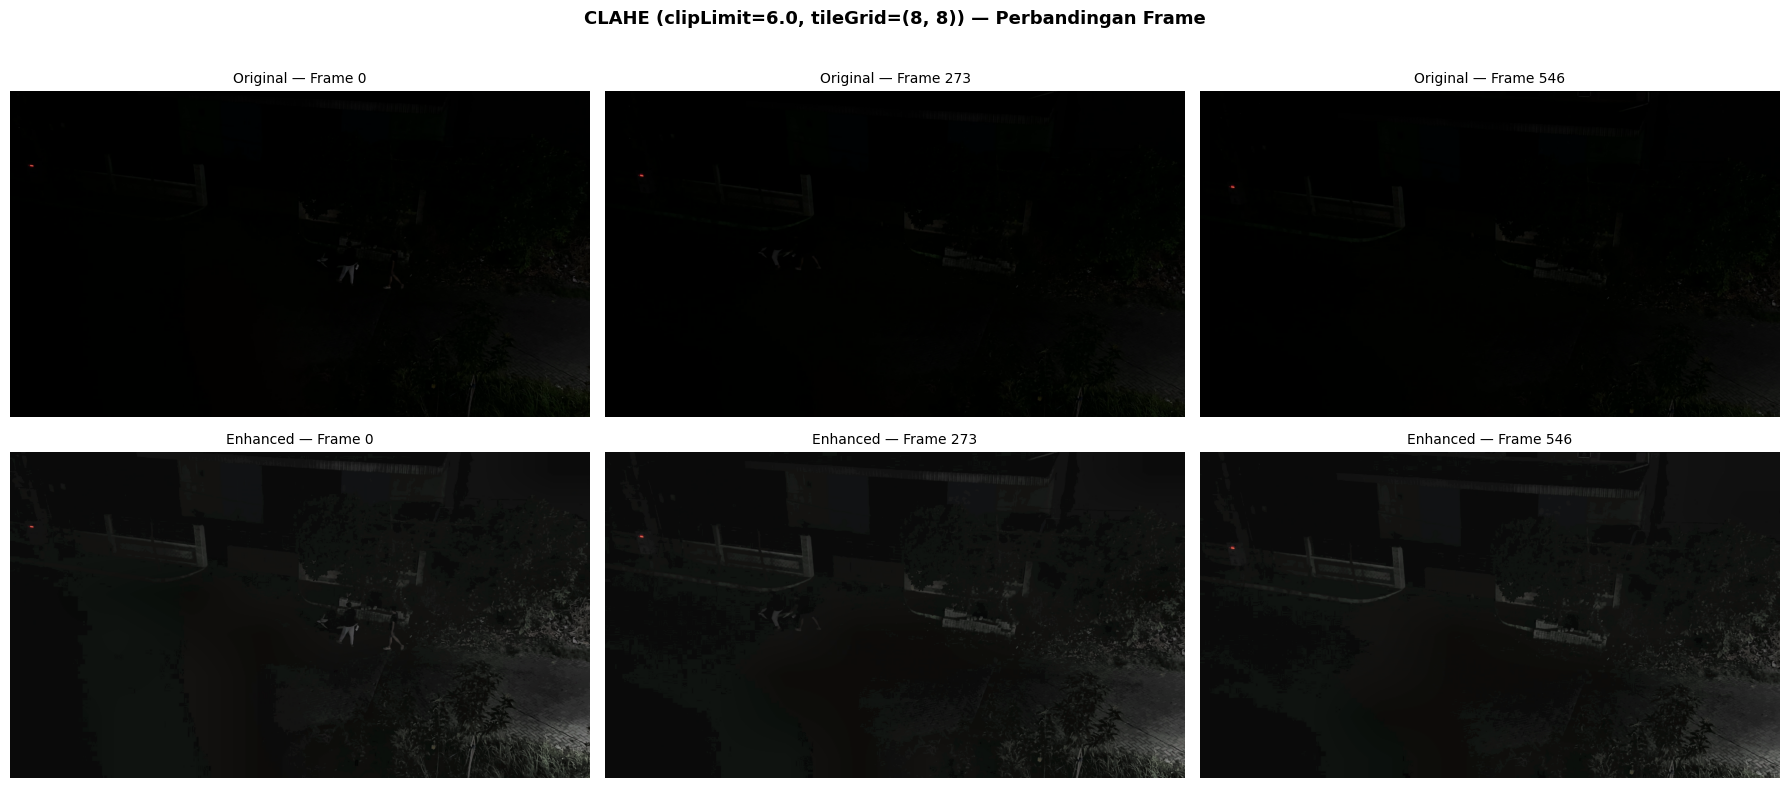

✅ Gambar perbandingan tersimpan.


In [10]:
import matplotlib.pyplot as plt

real_paths     = sorted(glob.glob(os.path.join(FRAMES_DIR,   "*.png")))
enhanced_paths = sorted(glob.glob(os.path.join(ENHANCED_DIR, "*.png")))

RESULTS_DIR = os.path.join(REPO_ROOT, "results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Ambil 3 sample frame (awal, tengah, akhir)
indices = [0, len(real_paths) // 2, len(real_paths) - 1]

fig, axes = plt.subplots(2, len(indices), figsize=(18, 8))
fig.suptitle(f"CLAHE (clipLimit={CLIP_LIMIT}, tileGrid={TILE_GRID_SIZE}) — Perbandingan Frame",
             fontsize=13, fontweight="bold", y=1.01)

for col, idx in enumerate(indices):
    real     = cv2.cvtColor(cv2.imread(real_paths[idx]),     cv2.COLOR_BGR2RGB)
    enhanced = cv2.cvtColor(cv2.imread(enhanced_paths[idx]), cv2.COLOR_BGR2RGB)

    axes[0, col].imshow(real)
    axes[0, col].set_title(f"Original — Frame {idx}", fontsize=10)
    axes[0, col].axis("off")

    axes[1, col].imshow(enhanced)
    axes[1, col].set_title(f"Enhanced — Frame {idx}", fontsize=10)
    axes[1, col].axis("off")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"comparison-clahe-{VIDEO_NAME}.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gambar perbandingan tersimpan.")

---
## Step 4 — Evaluasi Metrik (PSNR & SSIM)

In [11]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim
import random

# Hitung PSNR & SSIM pada sample 30 frame acak
SAMPLE_SIZE = min(30, len(real_paths))
sample_idx  = sorted(random.sample(range(len(real_paths)), SAMPLE_SIZE))

psnr_list, ssim_list = [], []

for idx in sample_idx:
    orig = cv2.imread(real_paths[idx],     cv2.IMREAD_GRAYSCALE)
    enh  = cv2.imread(enhanced_paths[idx], cv2.IMREAD_GRAYSCALE)

    psnr_list.append(psnr(orig, enh, data_range=255))
    ssim_list.append(ssim(orig, enh, data_range=255))

avg_psnr = np.mean(psnr_list)
avg_ssim = np.mean(ssim_list)

print(f"📊 Evaluasi Metrik (sample {SAMPLE_SIZE} frame)")
print(f"   Avg PSNR : {avg_psnr:.4f} dB")
print(f"   Avg SSIM : {avg_ssim:.4f}")

📊 Evaluasi Metrik (sample 30 frame)
   Avg PSNR : 23.6314 dB
   Avg SSIM : 0.1440


---
## Step 5 — Gabungkan Frame menjadi Video

In [12]:
images = sorted([
    f for f in os.listdir(ENHANCED_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
])

if not images:
    raise RuntimeError(f"Tidak ada frame ditemukan di {ENHANCED_DIR}")

first_frame = cv2.imread(os.path.join(ENHANCED_DIR, images[0]))
h, w, _     = first_frame.shape

print(f"🎬 Menggabungkan {len(images)} frame → {OUTPUT_VIDEO}")
print(f"   Resolusi : {w} x {h}")
print(f"   FPS      : {fps:.2f}")
print()

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps, (w, h))

for i, name in enumerate(images):
    frame = cv2.imread(os.path.join(ENHANCED_DIR, name))
    writer.write(frame)

    if i % 100 == 0:
        print(f"  [{i:>6}/{len(images)}] digabungkan...")

writer.release()
print(f"\n✅ Video berhasil disimpan: {OUTPUT_VIDEO}")

🎬 Menggabungkan 547 frame → /Users/fayyazi/programing/git/low-light-video-enhancement/output/output-clahe-motor.mp4
   Resolusi : 3840 x 2160
   FPS      : 29.22

  [     0/547] digabungkan...
  [   100/547] digabungkan...
  [   200/547] digabungkan...
  [   300/547] digabungkan...
  [   400/547] digabungkan...
  [   500/547] digabungkan...

✅ Video berhasil disimpan: /Users/fayyazi/programing/git/low-light-video-enhancement/output/output-clahe-motor.mp4
